# Q-variance for S\&P 500 with half-hour time increments
This notebook tests to see if q-variance holds when the time step is shortened from one day to half an hour.

## 1. Read data and generate log returns

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import binned_statistic

CSV_FILE = "30_min_SPY_2008-2021.csv"

df = pd.read_csv(CSV_FILE)
df['date'] = pd.to_datetime(df['date'])
prices = df['Close'].dropna()
#prices = prices.sort_index()
print(f"Loaded {len(prices):,} daily prices")

log_returns = np.log(prices / prices.shift(1)).dropna()


Loaded 57,830 daily prices


## 2. Compute scaled q-variance data
Compute z and v for periods T of 1 to 50 days. Returns are calculated each half hour, and a trading day is 6.5 hours long, so scale v by a factor 13 and z by sqrt(13).

In [32]:
rows = []
scale = np.sqrt(252)

print("Computing Q-Variance curve for T = 1 to 26 weeks...")
HORIZONS = 13*(np.arange(50)+1)   # does 1 to 100 days
for T in HORIZONS:
    i = 0
    while i + T <= len(log_returns):
        window = log_returns[i:i+T]     # T points
        if len(window) < T * 0.8:
            break

        x = window.sum()   # total price change over the period
        sigma = np.std(window, ddof=0) * scale      # ddof=0 means divisor is N, not N-1
        varcur = sigma**2
        z_raw = x / np.sqrt(T / 252.0)

        # REJECT BAD WINDOWS
        if not (np.isfinite(sigma) and sigma > 0 and np.isfinite(z_raw)):
            i += T
            continue

        rows.append({          # append row of data for this period
            "T": T,
            "z_raw": float(z_raw),
            "var": float(varcur)
        })
        i += T

df = pd.DataFrame(rows)

# CLEAN BEFORE DE-MEANING 
df = df[np.isfinite(df['z_raw']) & np.isfinite(df['var']) & (df['var'] > 0)]

# NOW de-mean safely, this step groups by T, and subtracts the group mean 
df["z"] = df.groupby(["T"])["z_raw"].transform(lambda g: g - g.mean())

df = df.drop(columns="z_raw")
df = df.dropna().reset_index(drop=True)  # Final clean, can save as e.g. parquet file

# times are 7:30, 8:00, 8:30, 9:00, 9:30, 10:00, 10:30, 11:00, 11:30, 12:00, 12:30, 13:00, 13:30 (14:00 excluded)
Tscale = 13  # there are now 13 time points in one day, so scale variance by 13 and z by sqrt(13)
df["z"] = np.sqrt(13)*df["z"]
df["var"] = 13*df["var"]

print(f"Generated {len(df["z"]):,} data points")



Computing Q-Variance curve for T = 1 to 26 weeks...
Generated 19,991 data points


## 4. Plot the q-variance curve
Periods T are from 1 to 50 days. Note that the time series is 2008-2021 so only contains about 13 years of data.


Q-Variance Fit Results:
  R²   = 0.9220


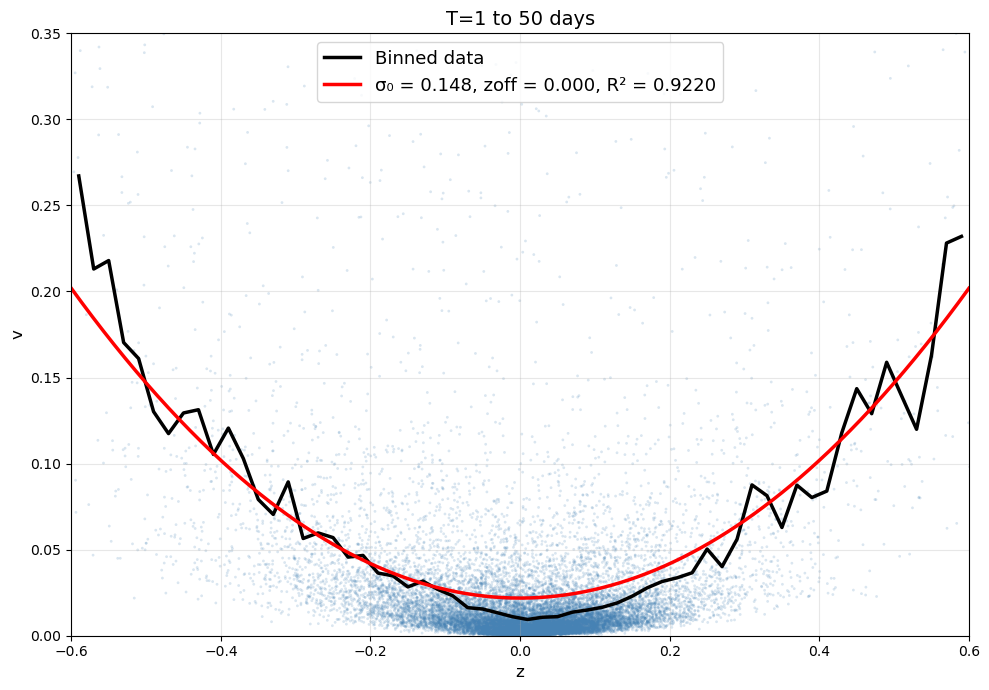

In [33]:
def q_variance_model(z, sigma_0_sq, zoff):
    return sigma_0_sq + (z - zoff)**2 / 2

# Binning
zmax = 0.6
Z_BINS = np.linspace(-zmax, zmax, 61)
bin_means, bin_edges, _ = binned_statistic(df["z"], df["var"], statistic='mean', bins=Z_BINS)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
valid = ~np.isnan(bin_means)

# Fit
popt, pcov = curve_fit(q_variance_model, bin_centers[valid], bin_means[valid],
                       p0=[0.1**2, 0.0], bounds=([0.0, -0.1], [0.5, 0.1]))
sigma_0_sq_fit, zoff_fit = popt
#sigma_0_sq_fit = sigma_0_sq*252  # do not fit, use theoretical curve but annualized
zoff_fit = 0

#perr = np.sqrt(np.diag(pcov))

# R²
#predicted = q_variance_model(bin_centers[valid], *popt)
predicted = q_variance_model(bin_centers[valid], sigma_0_sq_fit, 0)
ss_res = np.sum((bin_means[valid] - predicted)**2)
ss_tot = np.sum((bin_means[valid] - np.mean(bin_means[valid]))**2)
r_squared = 1 - ss_res / ss_tot

print(f"\nQ-Variance Fit Results:")
#print(f"  σ₀   = {sigma_0_sq_fit:.4f} ± {perr[0]:.4f}")
#print(f"  zoff = {zoff_fit:.4f} ± {perr[1]:.4f}")
print(f"  R²   = {r_squared:.4f}")

plt.figure(figsize=(10, 7))

# Scatter plot
plt.scatter(df["z"], df["var"], c='steelblue', alpha=0.1*2, s=1*4, edgecolor='none')

# Binned data
plt.plot(bin_centers[valid], bin_means[valid], 'k-', lw=2.5, label='Binned data')

# Q-Variance fit, note results will vary because model is unstable
z_fine = np.linspace(-zmax, zmax, 500)
sigma_0_fit = np.sqrt(sigma_0_sq_fit)
plt.plot(z_fine, q_variance_model(z_fine, sigma_0_sq_fit, 0),
         color='red', lw=2.5,
         label=f'σ₀ = {sigma_0_fit:.3f}, zoff = {zoff_fit:.3f}, R² = {r_squared:.4f}')

plt.xlabel('z', fontsize=12)
plt.ylabel('v', fontsize=12)
plt.title('T=1 to 50 days', fontsize=14)
plt.xlim(-0.6, 0.6)
plt.ylim(0, 0.35)
plt.grid(alpha=0.3)
plt.legend(fontsize=13, loc='upper center')
plt.tight_layout()

# Save for publication
# plt.savefig("Q_Variance_Parabola.png", dpi=300, bbox_inches='tight')
# plt.savefig("Q_Variance_Parabola.pdf", bbox_inches='tight')
plt.show()


The plot shows that q-variance applies for time steps of less than one day. It can also be checked that the results do not depend on the exact time of day the price is measured, so for example the price at mid-day can be used instead of the closing price, as long as the same time is used each day (for equal spacing).